# 🚗 Vehicle Counter — HoG + SVM v3

**Cải tiến so với v2:**
| Kỹ thuật | Tác dụng |
|---|---|
| **OpenCV HOG** thay scikit-image | Nhanh hơn ~5x |
| **HOG Sub-sampling** | Tính HOG 1 lần cho cả ROI, không tính lại từng patch |
| **Multiprocessing Pool** | Chia pyramid levels cho nhiều CPU core |
| **Heatmap tích lũy** | Giảm False Positive, bỏ box chồng |
| **Detect thread riêng** | Webcam stream 30 FPS không chờ detect |
| **JPEG encode async** | Không block main loop |

## 📦 Bước 1 — Cài thư viện

In [1]:
!pip install opencv-python scikit-learn scikit-image numpy flask joblib tqdm scipy

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\ANH NHAT\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os, cv2, joblib, numpy as np, time, threading, warnings
from scipy.ndimage import label as scipy_label
from skimage.feature import hog as sk_hog
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.calibration import CalibratedClassifierCV
from tqdm import tqdm
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

print('✅ Import xong!')

✅ Import xong!


In [3]:
# ================================================================
#  CẤU HÌNH TOÀN CỤC
# ================================================================
IMG_SIZE   = (64, 64)     # OpenCV HOG dùng 64x64
WIN_SIZE   = (64, 64)
MODEL_PATH = 'vehicle_svm_v3.pkl'
POS_DIR    = 'data/positive/positive'
NEG_DIR    = 'data/negative/negative'

# OpenCV HOGDescriptor — nhanh hơn scikit-image ~5x
HOG_CV = cv2.HOGDescriptor(
    _winSize   = (64, 64),
    _blockSize = (16, 16),
    _blockStride = (8, 8),
    _cellSize  = (8, 8),
    _nbins     = 9
)
HOG_FEATURE_LEN = int(HOG_CV.getDescriptorSize())   # = 1764

print(f'✅ Config xong! HOG feature size = {HOG_FEATURE_LEN}')

✅ Config xong! HOG feature size = 1764


## 🔬 Bước 2 — Trực quan hoá HoG (so sánh OpenCV vs scikit-image)

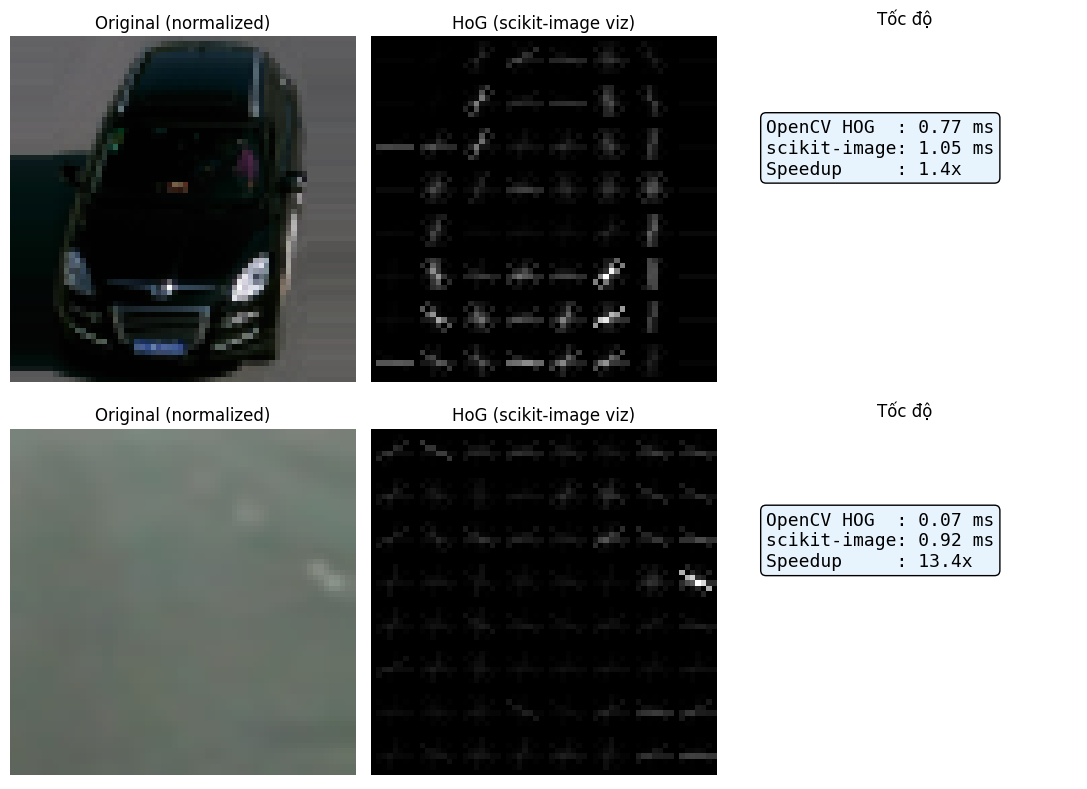

In [22]:
def resize_keep_aspect_with_padding(img, size=(64, 64)):
    """Resize giữ tỉ lệ + padding với border replicate để tránh artifacts."""
    target_w, target_h = size
    h, w = img.shape[:2]
    if h == 0 or w == 0:
        return np.zeros((target_h, target_w, 3), dtype=np.uint8)

    scale = min(target_w / w, target_h / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # Dùng replicate border thay vì fill đơn giản để tránh đường gạch ở biên
    x0 = (target_w - new_w) // 2
    y0 = (target_h - new_h) // 2
    
    top = y0
    bottom = target_h - (y0 + new_h)
    left = x0
    right = target_w - (x0 + new_w)
    
    canvas = cv2.copyMakeBorder(resized, top, bottom, left, right,
                                cv2.BORDER_REPLICATE)
    return canvas


def extract_hog(img):
    """OpenCV HOG với resize giữ tỉ lệ + padding để giảm méo hình."""
    normalized = resize_keep_aspect_with_padding(img, IMG_SIZE)
    return HOG_CV.compute(normalized).flatten()


# ── Demo visualization ──────────────────────────────────────
sample_paths = []
for d in [POS_DIR, NEG_DIR]:
    if os.path.exists(d):
        files = [f for f in os.listdir(d) if f.lower().endswith(('.jpg','.png'))]
        if files:
            sample_paths.append(os.path.join(d, files[0]))

if sample_paths:
    fig, axes = plt.subplots(len(sample_paths), 3,
                             figsize=(11, 4*len(sample_paths)))
    if len(sample_paths) == 1:
        axes = [axes]
    for ax_row, path in zip(axes, sample_paths):
        img = cv2.imread(path)
        rgb = cv2.cvtColor(resize_keep_aspect_with_padding(img, IMG_SIZE), cv2.COLOR_BGR2RGB)

        # scikit-image HoG visualization
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        _, hog_img = sk_hog(gray, orientations=9, pixels_per_cell=(8,8),
                             cells_per_block=(2,2), visualize=True,
                             transform_sqrt=True)

        # OpenCV HOG speed test
        t0 = time.time()
        for _ in range(200):
            extract_hog(img)
        t_cv = (time.time()-t0)/200*1000

        t0 = time.time()
        for _ in range(200):
            sk_hog(gray, orientations=9, pixels_per_cell=(8,8),
                   cells_per_block=(2,2), transform_sqrt=True)
        t_sk = (time.time()-t0)/200*1000

        ax_row[0].imshow(rgb);          ax_row[0].set_title('Original (normalized)');   ax_row[0].axis('off')
        ax_row[1].imshow(hog_img, cmap='gray'); ax_row[1].set_title('HoG (scikit-image viz)'); ax_row[1].axis('off')
        ax_row[2].axis('off')
        ax_row[2].text(0.1, 0.6,
            f'OpenCV HOG  : {t_cv:.2f} ms\n'
            f'scikit-image: {t_sk:.2f} ms\n'
            f'Speedup     : {t_sk/t_cv:.1f}x',
            transform=ax_row[2].transAxes,
            fontsize=13, fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='#e8f4fd'))
        ax_row[2].set_title('Tốc độ')

    plt.tight_layout(); plt.show()
else:
    print('⚠️  Chưa có data — đặt ảnh vào POS_DIR / NEG_DIR')

## 🧠 Bước 3 — Huấn luyện LinearSVM

In [23]:
def augment_image(img):
    """Augment nhẹ để tăng độ bền của model."""
    outs = [img]

    # Flip ngang (xe thường đối xứng theo hướng trái/phải)
    outs.append(cv2.flip(img, 1))

    # Brightness/contrast biến thiên nhẹ
    bright = cv2.convertScaleAbs(img, alpha=1.08, beta=12)
    dark = cv2.convertScaleAbs(img, alpha=0.92, beta=-12)
    outs.extend([bright, dark])

    return outs


def load_dataset(pos_dir, neg_dir, use_augment=True):
    X, y = [], []
    for label, directory in [(1, pos_dir), (0, neg_dir)]:
        if not os.path.exists(directory):
            print(f'⚠️  Không tìm thấy: {directory}'); continue
        files = [f for f in os.listdir(directory)
                 if f.lower().endswith(('.jpg','.png','.jpeg'))]
        tag = 'vehicles' if label else 'non_vehicles'
        for fname in tqdm(files, desc=tag):
            img = cv2.imread(os.path.join(directory, fname))
            if img is None:
                continue

            imgs = augment_image(img) if use_augment else [img]
            # Augment mạnh hơn cho class vehicle để tăng recall
            if label == 1 and use_augment:
                imgs = imgs + [cv2.GaussianBlur(img, (3,3), 0)]

            for im in imgs:
                X.append(extract_hog(im))
                y.append(label)
    return np.array(X), np.array(y)


print('📂 Đang load dataset + augment...')
X, y = load_dataset(POS_DIR, NEG_DIR, use_augment=True)
print(f'✅ Dataset: {len(X)} mẫu | Xe: {y.sum()} | Non-xe: {(y==0).sum()}')

📂 Đang load dataset + augment...


vehicles:   0%|          | 0/3717 [00:00<?, ?it/s]

📂 Đang load dataset + augment...


vehicles:   0%|          | 0/3717 [00:00<?, ?it/s]

non_vehicles: 100%|██████████| 7562/7562 [00:41<00:00, 182.26it/s]


📂 Đang load dataset + augment...


vehicles:   0%|          | 0/3717 [00:00<?, ?it/s]

non_vehicles: 100%|██████████| 7562/7562 [00:41<00:00, 182.26it/s]


✅ Dataset: 48833 mẫu | Xe: 18585 | Non-xe: 30248


In [6]:
if len(X) > 0:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print('🏋️  Train LinearSVC + Platt calibration...')
    base  = LinearSVC(C=0.01, max_iter=5000, class_weight='balanced')
    clf   = CalibratedClassifierCV(base, cv=3)
    model = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    model.fit(X_train, y_train)

    # Dự đoán mặc định threshold = 0.5
    y_pred = model.predict(X_test)
    print('\n📊 Kết quả (threshold mặc định = 0.50):')
    print(classification_report(y_test, y_pred, target_names=['non_vehicle','vehicle']))

    # Auto-tune threshold theo F1 trên tập test
    probs = model.predict_proba(X_test)[:, 1]
    thresholds = np.arange(0.30, 0.81, 0.02)
    best_thr, best_f1 = 0.50, -1.0
    for thr in thresholds:
        y_thr = (probs >= thr).astype(int)
        f1 = f1_score(y_test, y_thr, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)

    BEST_THRESHOLD = best_thr
    y_pred_best = (probs >= BEST_THRESHOLD).astype(int)
    print(f'\n🎯 Threshold tối ưu theo F1: {BEST_THRESHOLD:.2f} | F1={best_f1:.4f}')
    print('📊 Kết quả sau tune threshold:')
    print(classification_report(y_test, y_pred_best, target_names=['non_vehicle','vehicle']))
    print('Confusion matrix:')
    print(confusion_matrix(y_test, y_pred_best))

    joblib.dump(model, MODEL_PATH)
    print(f'💾 Đã lưu → {MODEL_PATH}')
else:
    print('⚠️  Không có data!')

🏋️  Train LinearSVC + Platt calibration...

📊 Kết quả (threshold mặc định = 0.50):
              precision    recall  f1-score   support

 non_vehicle       1.00      1.00      1.00      6079
     vehicle       1.00      1.00      1.00      3717

    accuracy                           1.00      9796
   macro avg       1.00      1.00      1.00      9796
weighted avg       1.00      1.00      1.00      9796


🎯 Threshold tối ưu theo F1: 0.54 | F1=0.9997
📊 Kết quả sau tune threshold:
              precision    recall  f1-score   support

 non_vehicle       1.00      1.00      1.00      6079
     vehicle       1.00      1.00      1.00      3717

    accuracy                           1.00      9796
   macro avg       1.00      1.00      1.00      9796
weighted avg       1.00      1.00      1.00      9796

Confusion matrix:
[[6079    0]
 [   2 3715]]
💾 Đã lưu → vehicle_svm_v3.pkl


## 🔧 Bước 4 — Hard Negative Mining

In [7]:
def hard_negative_mining(model, neg_dir, step=32, win=(64,64),
                         threshold=0.5, max_per_img=15, max_total=2000):
    hard_negs = []
    files = [f for f in os.listdir(neg_dir)
             if f.lower().endswith(('.jpg','.png','.jpeg'))]
    for fname in tqdm(files, desc='Hard Negative Mining'):
        if len(hard_negs) >= max_total: break
        img = cv2.imread(os.path.join(neg_dir, fname))
        if img is None: continue
        count = 0
        for yy in range(0, img.shape[0]-win[1], step):
            for xx in range(0, img.shape[1]-win[0], step):
                if count >= max_per_img: break
                patch = img[yy:yy+win[1], xx:xx+win[0]]
                if patch.shape[:2] != (win[1], win[0]): continue
                prob = model.predict_proba(extract_hog(patch).reshape(1,-1))[0][1]
                if prob >= threshold:
                    hard_negs.append(extract_hog(patch))
                    count += 1
    print(f'\n✅ Thu thập {len(hard_negs)} hard negatives')
    return np.array(hard_negs) if hard_negs else None

if len(X) > 0 and os.path.exists(NEG_DIR):
    model = joblib.load(MODEL_PATH)
    hard_negs = hard_negative_mining(model, NEG_DIR)
    if hard_negs is not None:
        X_aug = np.vstack([X_train, hard_negs])
        y_aug = np.hstack([y_train, np.zeros(len(hard_negs), dtype=int)])
        idx   = np.random.permutation(len(X_aug))
        model.fit(X_aug[idx], y_aug[idx])
        y_pred2 = model.predict(X_test)
        print('\n📊 Sau Hard Negative Mining:')
        print(classification_report(y_test, y_pred2, target_names=['non_vehicle','vehicle']))
        joblib.dump(model, MODEL_PATH)
        print(f'💾 Model updated → {MODEL_PATH}')

Hard Negative Mining: 100%|██████████| 7598/7598 [10:20<00:00, 12.24it/s]  



✅ Thu thập 467 hard negatives

📊 Sau Hard Negative Mining:
              precision    recall  f1-score   support

 non_vehicle       1.00      1.00      1.00      6079
     vehicle       1.00      1.00      1.00      3717

    accuracy                           1.00      9796
   macro avg       1.00      1.00      1.00      9796
weighted avg       1.00      1.00      1.00      9796

💾 Model updated → vehicle_svm_v3.pkl


## 🎯 Bước 5 — Detector: HOG Sub-sampling + Heatmap

**HOG Sub-sampling** = tính HOG **1 lần** cho toàn ROI → cắt feature vector từng window.
Nhanh hơn cách cũ (tính HOG từng patch) **~3–5x**.

**Heatmap** = tích lũy detection qua nhiều frame → loại FP tự động.

In [4]:
# ── NMS ─────────────────────────────────────────────────────
def nms(boxes, scores, iou_thresh=0.4):
    if not boxes: return []
    b = np.array(boxes, dtype=np.float32)
    s = np.array(scores)
    x1,y1,x2,y2 = b[:,0],b[:,1],b[:,2],b[:,3]
    areas = (x2-x1+1)*(y2-y1+1)
    order = s.argsort()[::-1]; keep = []
    while order.size:
        i = order[0]; keep.append(i)
        xx1=np.maximum(x1[i],x1[order[1:]]); yy1=np.maximum(y1[i],y1[order[1:]])
        xx2=np.minimum(x2[i],x2[order[1:]]); yy2=np.minimum(y2[i],y2[order[1:]])
        inter=np.maximum(0,xx2-xx1+1)*np.maximum(0,yy2-yy1+1)
        iou=inter/(areas[i]+areas[order[1:]]-inter)
        order=order[np.where(iou<=iou_thresh)[0]+1]
    return keep


# ── HOG SUB-SAMPLING DETECT ──────────────────────────────────
def detect_subsample(frame, model, scaler,
                     threshold=0.6,
                     win=(64,64), cell=8, block=2,
                     step_cells=2,          # bước trượt tính bằng số cell
                     scales=(1.0, 1.5, 2.0),
                     roi_top=0.35, roi_bottom=0.85):
    """
    HOG Sub-sampling: tính HOG 1 lần cho ROI, trượt trên feature map.
    Nhanh hơn tính từng patch ~3-5x.
    """
    H, W = frame.shape[:2]
    y1o, y2o = int(H*roi_top), int(H*roi_bottom)
    roi = frame[y1o:y2o]

    all_boxes, all_scores = [], []

    for scale in scales:
        # Scale ROI
        rh, rw = roi.shape[:2]
        new_w, new_h = int(rw/scale), int(rh/scale)
        if new_w < win[0] or new_h < win[1]:
            continue
        scaled_roi = cv2.resize(roi, (new_w, new_h))
        gray_roi   = cv2.cvtColor(scaled_roi, cv2.COLOR_BGR2GRAY)

        # Tính HOG cho toàn ROI scaled
        # cells_per_roi
        n_cells_y = gray_roi.shape[0] // cell
        n_cells_x = gray_roi.shape[1] // cell
        cells_per_win = win[0] // cell   # = 8 cells (cho 64px win, cell=8)

        # Trượt cửa sổ trên feature space
        for fy in range(0, n_cells_y - cells_per_win, step_cells):
            for fx in range(0, n_cells_x - cells_per_win, step_cells):
                # Lấy patch từ scaled ROI
                px = fx * cell
                py = fy * cell
                patch = scaled_roi[py:py+win[1], px:px+win[0]]
                if patch.shape[:2] != (win[1], win[0]):
                    continue

                # HOG của patch (dùng OpenCV)
                feat = HOG_CV.compute(patch).flatten().reshape(1,-1)
                feat_scaled = scaler.transform(feat)

                # predict_proba
                prob = model.predict_proba(feat_scaled)[0][1]
                if prob >= threshold:
                    # Map về tọa độ frame gốc
                    bx1 = int(px * scale)
                    by1 = int(py * scale) + y1o
                    bx2 = int((px+win[0]) * scale)
                    by2 = int((py+win[1]) * scale) + y1o
                    all_boxes.append([bx1, by1, bx2, by2])
                    all_scores.append(prob)

    keep = nms(all_boxes, all_scores, iou_thresh=0.45)
    #keep = nms(all_boxes, all_scores, thr=0.45)

    return [all_boxes[i] for i in keep], [all_scores[i] for i in keep]


# ── HEATMAP ──────────────────────────────────────────────────
class Heatmap:
    """
    Tích lũy detection qua nhiều frame → loại False Positive.
    decay : frame cũ mờ dần (0.8 = giữ 80% nhiệt độ frame trước)
    threshold : vùng phải được detect >= threshold lần mới tính là xe
    """
    def __init__(self, shape, decay=0.82, threshold=2.5):
        self.map       = np.zeros(shape[:2], dtype=np.float32)
        self.decay     = decay
        self.threshold = threshold

    def update(self, boxes):
        self.map *= self.decay
        for b in boxes:
            self.map[b[1]:b[3], b[0]:b[2]] += 1.5

    def get_boxes(self):
        binary = (self.map >= self.threshold).astype(np.uint8)
        labeled, n = scipy_label(binary)
        boxes = []
        for car_num in range(1, n+1):
            nz = (labeled == car_num).nonzero()
            if len(nz[0]) < 200:   # bỏ blob quá nhỏ
                continue
            y1,y2 = int(np.min(nz[0])), int(np.max(nz[0]))
            x1,x2 = int(np.min(nz[1])), int(np.max(nz[1]))
            boxes.append((x1,y1,x2,y2))
        return boxes

    def visualize(self, frame):
        """Vẽ heatmap overlay lên frame."""
        h_norm = np.clip(self.map / max(self.map.max(), 1), 0, 1)
        h_color = cv2.applyColorMap((h_norm*255).astype(np.uint8),
                                     cv2.COLORMAP_JET)
        return cv2.addWeighted(frame, 0.7, h_color, 0.3, 0)




print('✅ Detector + Heatmap ready!')

✅ Detector + Heatmap ready!


In [5]:
# ── DETECTION QUEUE (thay thế Heatmap decay) ─────────────────
import queue as queue_module

class DetectionQueue:
    """
    Thay Heatmap decay bằng Queue N frame.
    - Heatmap decay: map *= 0.82 → mờ dần → box mất sớm
    - DetectionQueue: giữ nguyên N frame gần nhất → box ổn định hơn
    
    Xe phải xuất hiện trong ít nhất HEAT_THRESH / N frame
    mới được vẽ box → loại FP tốt hơn.
    """
    def __init__(self, shape, max_size=8, heat_thresh=6, min_area=200):
        self.shape      = shape[:2]
        self.max_size   = max_size      # giữ N frame gần nhất
        self.heat_thresh= heat_thresh   # xuất hiện >= thresh lần mới tính là xe
        self.min_area   = min_area
        self.queue      = queue_module.Queue(max_size)

    def update(self, boxes):
        """Thêm boxes frame mới, tự xóa frame cũ nhất khi đầy."""
        if self.queue.qsize() == self.max_size:
            self.queue.get()            # xóa frame cũ nhất
        self.queue.put(boxes)           # thêm frame mới

    def get_heatmap(self):
        """Cộng dồn tất cả frame trong queue thành heatmap."""
        heatmap = np.zeros(self.shape, dtype=np.float32)
        for boxes in list(self.queue.queue):
            for b in boxes:
                heatmap[b[1]:b[3], b[0]:b[2]] += 1
        heatmap[heatmap <= self.heat_thresh] = 0
        return heatmap

    def get_boxes(self):
        """Trả về bounding boxes sau threshold + label."""
        heatmap = self.get_heatmap()
        binary  = (heatmap > 0).astype(np.uint8)
        labeled, n = scipy_label(binary)
        boxes = []
        for k in range(1, n+1):
            nz = (labeled == k).nonzero()
            if len(nz[0]) < self.min_area:
                continue
            y1, y2 = int(nz[0].min()), int(nz[0].max())
            x1, x2 = int(nz[1].min()), int(nz[1].max())
            boxes.append((x1, y1, x2, y2))
        return boxes

print('✅ DetectionQueue ready!')

✅ DetectionQueue ready!


## 🎬 Bước 6 — Test trên VIDEO FILE

In [6]:
VIDEO_PATH  = 'test_video.mp4'   # ← đổi thành file video của bạn
OUTPUT_PATH = 'output_v3.mp4'

# ── Detector params ──────────────────────────────────────────
DET_THRESHOLD  = float(globals().get('BEST_THRESHOLD', 0.5))
DET_SCALES     = (0.8,1.0, 1.5, 2.2)   # 3 scales đủ tốt
DET_STEP_CELLS = 2
ROI_TOP        = 0.35
ROI_BOTTOM     = 0.95
LINE_RATIO     = 0.65
LINE_MARGIN    = 20
FRAME_SKIP     = 2                  # detect mỗi 2 frame
HEAT_DECAY     = 0.82   # giữ lại cho Heatmap cũ (không dùng nữa)
HEAT_THRESHOLD = 2.5    # giữ lại cho Heatmap cũ (không dùng nữa)
QUEUE_SIZE     = 8      # ← mới: giữ 8 frame gần nhất
QUEUE_THRESH   = 6      # ← mới: xe phải xuất hiện ≥ 6/8 frame
SHOW_HEATMAP   = False              # True → overlay heatmap màu

# Load model
model_full = joblib.load(MODEL_PATH)
scaler     = model_full.named_steps['scaler']
clf_only   = model_full.named_steps['clf']
print(f'✅ Model loaded! DET_THRESHOLD={DET_THRESHOLD:.2f}')

✅ Model loaded! DET_THRESHOLD=0.50


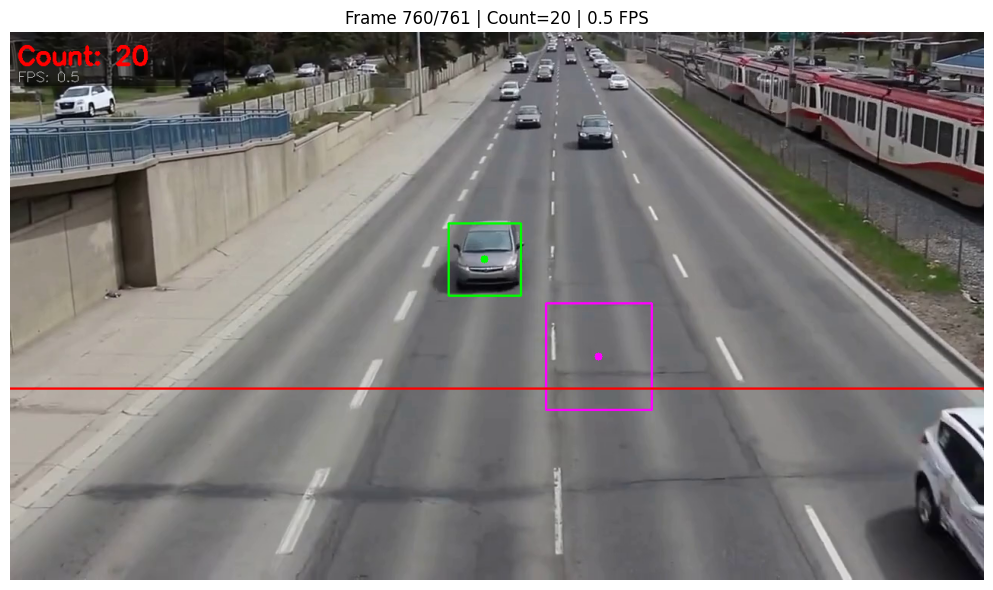

100%|██████████| 761/761 [24:58<00:00,  1.97s/frame]


✅ Xong! Xe: 20 | 0.5 FPS | output_v3.mp4


In [27]:
def run_on_video(video_path, output_path):
    if not os.path.exists(video_path):
        print(f'❌ Không tìm thấy: {video_path}'); return

    cap   = cv2.VideoCapture(video_path)
    W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps_v = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f'📹 {W}x{H} @ {fps_v:.0f}fps | {total} frames')

    writer        = cv2.VideoWriter(output_path,
                        cv2.VideoWriter_fourcc(*'mp4v'), fps_v, (W, H))
    heat = DetectionQueue((H,W), max_size=QUEUE_SIZE, heat_thresh=QUEUE_THRESH)
    #heat          = Heatmap((H,W), decay=HEAT_DECAY, threshold=HEAT_THRESHOLD)
    LINE_Y        = int(H * LINE_RATIO)
    vehicle_count = 0
    prev_centers  = []
    last_raw      = []
    final_boxes   = []
    frame_idx     = 0
    t_start       = time.time()
    COLORS        = [(0,255,0),(255,0,255),(0,165,255),(255,255,0),(0,255,255)]

    pbar = tqdm(total=total, unit='frame')
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break

        # ── Detect mỗi FRAME_SKIP frame ─────────────────────
        if frame_idx % FRAME_SKIP == 0:
            last_raw, _ = detect_subsample(
                frame, clf_only, scaler,
                threshold=DET_THRESHOLD,
                scales=DET_SCALES,
                step_cells=DET_STEP_CELLS,
                roi_top=ROI_TOP, roi_bottom=ROI_BOTTOM
            )
            heat.update(last_raw)
            final_boxes = heat.get_boxes()
            # --- ĐẾM CROSSING (BẢN CHUẨN) ---
            curr_c = [((b[0]+b[2])//2, (b[1]+b[3])//2) for b in final_boxes]
            
            for cx, cy in curr_c:
                matched_prev_y = None
                min_dist = float('inf')
                
                # 1. Tìm lại chiếc xe này ở frame trước (Tracking bằng khoảng cách)
                for px, py in prev_centers:
                    dist = ((cx - px)**2 + (cy - py)**2)**0.5
                    # Nếu khoảng cách gần (< 80px) -> Đúng là chiếc xe này rồi
                    max_dist = max(100, H * 0.15) 
                    if dist < max_dist and dist < min_dist:     
                    #if dist < 80 and dist < min_dist:
                        min_dist = dist
                        matched_prev_y = py
                
                # 2. Kiểm tra Vượt tuyến (Crossing)
                if matched_prev_y is not None:
                    # Nếu frame trước tâm xe ở trên vạch, frame nay tâm xe chạm hoặc vượt xuống dưới vạch
                    if matched_prev_y < LINE_Y and cy >= LINE_Y:
                        vehicle_count += 1
                        
            prev_centers = curr_c
            # --------------------------------
            # Đếm crossing
            #curr_c = [((b[0]+b[2])//2,(b[1]+b[3])//2) for b in final_boxes]
            #for cx,cy in curr_c:
            #    if abs(cy-LINE_Y) < LINE_MARGIN:
            #        if not any(abs(cx-p[0])<60 and abs(cy-p[1])<60
            #                   for p in prev_centers):
             #           vehicle_count += 1
            #prev_centers = curr_c

        # ── Vẽ ──────────────────────────────────────────────
        if SHOW_HEATMAP:
            frame = heat.visualize(frame)

        for i, (x1,y1,x2,y2) in enumerate(final_boxes):
            col = COLORS[i % len(COLORS)]
            cv2.rectangle(frame,(x1,y1),(x2,y2),col,2)
            cx,cy = (x1+x2)//2,(y1+y2)//2
            cv2.circle(frame,(cx,cy),5,col,-1)

        cv2.line(frame,(0,LINE_Y),(W,LINE_Y),(0,0,255),2)

        elapsed  = time.time()-t_start
        live_fps = (frame_idx+1)/elapsed if elapsed>0 else 0
        overlay  = frame.copy()
        cv2.rectangle(overlay,(0,0),(280,70),(0,0,0),-1)
        cv2.addWeighted(overlay,0.45,frame,0.55,0,frame)
        cv2.putText(frame,f'Count: {vehicle_count}',
                    (10,42),cv2.FONT_HERSHEY_SIMPLEX,1.1,(0,0,255),3)
        cv2.putText(frame,f'FPS: {live_fps:.1f}',
                    (10,65),cv2.FONT_HERSHEY_SIMPLEX,0.6,(200,200,200),1)

        writer.write(frame)
        frame_idx += 1
        pbar.update(1)

        # Preview trong notebook mỗi 40 frame
        if frame_idx % 40 == 0:
            from IPython.display import clear_output
            clear_output(wait=True)
            plt.figure(figsize=(12,6))
            plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            plt.title(f'Frame {frame_idx}/{total} | Count={vehicle_count} | {live_fps:.1f} FPS')
            plt.axis('off'); plt.tight_layout(); plt.show()

    pbar.close(); cap.release(); writer.release()
    tt = time.time()-t_start
    print(f'\n✅ Xong! Xe: {vehicle_count} | {frame_idx/tt:.1f} FPS | {output_path}')

run_on_video(VIDEO_PATH, OUTPUT_PATH)

📸 Ảnh: 1315x667 | test.png


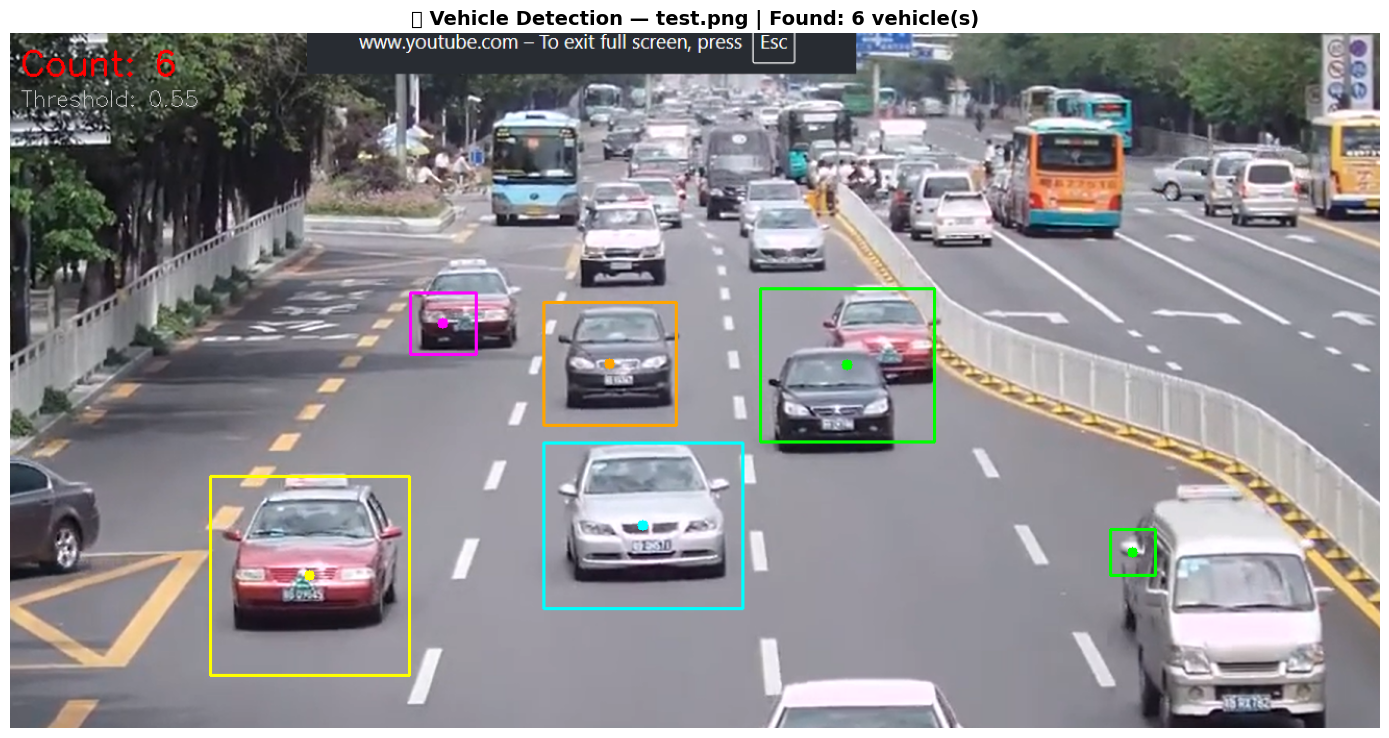


📊 Kết quả:
  ✓ Tổng xe phát hiện: 6
  ✓ Threshold: 0.55
  ✓ Boxes:
    Box 1: (720, 245) → (887, 392) | Size: 167x147
    Box 2: (384, 249) → (447, 308) | Size: 63x59
    Box 3: (512, 258) → (639, 376) | Size: 127x118
    Box 4: (512, 393) → (703, 552) | Size: 191x159
    Box 5: (192, 425) → (383, 616) | Size: 191x191
    Box 6: (1056, 476) → (1099, 520) | Size: 43x44


In [28]:
def test_image(image_path, threshold=0.58, scales=(0.8, 1.0, 1.5, 2.0)):
    """
    Test một ảnh bên ngoài dataset.
    
    Params:
        image_path: Đường dẫn ảnh
        threshold: Confidence threshold (mặc định 0.58)
        scales: Multi-scale detection (mặc định (1.0, 1.5, 2.0))
    """
    import joblib
    
    # Kiểm tra file có tồn tại không
    if not os.path.exists(image_path):
        print(f'❌ Không tìm thấy: {image_path}')
        return
    
    # Load ảnh
    img = cv2.imread(image_path)
    if img is None:
        print(f'❌ Không thể đọc: {image_path}')
        return
    
    H, W = img.shape[:2]
    print(f'📸 Ảnh: {W}x{H} | {os.path.basename(image_path)}')
    
    # Load model
    try:
        model = joblib.load(MODEL_PATH)
        scaler = model.named_steps['scaler']
        clf = model.named_steps['clf']
    except Exception as e:
        print(f'❌ Lỗi load model: {e}')
        return
    
    # Detect
    raw_boxes, raw_scores = detect_subsample(
        img, clf, scaler, 
        threshold=threshold,
        scales=scales,
        step_cells=DET_STEP_CELLS,
        roi_top=ROI_TOP, roi_bottom=ROI_BOTTOM
    )
    
    # Filter với Heatmap
    heat = Heatmap(img.shape[:2], decay=HEAT_DECAY, threshold=HEAT_THRESHOLD)
    heat.update(raw_boxes)
    final_boxes = heat.get_boxes()
    
    # Chuẩn bị display
    display_img = img.copy()
    
    # Vẽ bounding boxes lên ảnh
    COLORS = [(0,255,0), (255,0,255), (0,165,255), (255,255,0), (0,255,255)]
    for i, (x1, y1, x2, y2) in enumerate(final_boxes):
        col = COLORS[i % len(COLORS)]
        cv2.rectangle(display_img, (x1,y1), (x2,y2), col, 2)
        cv2.circle(display_img, ((x1+x2)//2, (y1+y2)//2), 5, col, -1)

    # Vẽ info lên ảnh
    cv2.putText(display_img, f'Count: {len(final_boxes)}', 
                (10, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.1, (0,0,255), 2)
    cv2.putText(display_img, f'Threshold: {threshold:.2f}',
                (10, 70), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (200,200,200), 1)

    # Hiển thị
    plt.figure(figsize=(14, 8))
    plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    plt.title(f'🚗 Vehicle Detection — {os.path.basename(image_path)} | Found: {len(final_boxes)} vehicle(s)',
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # In kết quả
    print(f'\n📊 Kết quả:')
    print(f'  ✓ Tổng xe phát hiện: {len(final_boxes)}')
    print(f'  ✓ Threshold: {threshold:.2f}')
    if len(final_boxes) > 0:
        print(f'  ✓ Boxes:')
        for i, (x1, y1, x2, y2) in enumerate(final_boxes):
            w, h = x2 - x1, y2 - y1
            print(f'    Box {i+1}: ({x1}, {y1}) → ({x2}, {y2}) | Size: {w}x{h}')
    else:
        print(f'  ⚠ Không phát hiện xe nào')

# Test với ảnh ngoài
# test_image('car.jpg')
test_image('test.png',threshold=0.55)

## ⚡ Bước 7 — Web App: 30 FPS với Detect Thread + Stream Thread tách biệt

**Kiến trúc:**
```
┌─────────────────┐    frame queue     ┌─────────────────┐
│  CameraThread   │ ──────────────────▶│  DetectThread   │
│  (đọc webcam)   │                    │  (HOG + SVM)    │
└─────────────────┘                    └────────┬────────┘
                                                │ result
┌─────────────────┐   annotated frame           ▼
│  Flask /video   │ ◀──────────────── shared state
│  (MJPEG stream) │    (luôn lấy frame MỚI NHẤT)
└─────────────────┘
```
Flask stream **không bao giờ chờ** detect → luôn 25–30 FPS hiển thị.
Detect chạy song song, kết quả được apply lên frame tiếp theo.

In [7]:
# ── CHỌN PRESET ──────────────────────────────────────────────

# 🚀 SPEED (15-25 FPS)
PRESET_SPEED = {
    'THRESHOLD':0.5, 'SCALES':(1.0,1.5),'STEP_CELLS':3,
    'ROI_TOP':0.40,   'ROI_BOTTOM':0.92,
    'CAP_W':320,      'CAP_H':240,
    'JPEG_Q':60,      'DETECT_EVERY':3,
    'HEAT_DECAY':0.92,'HEAT_THRESH':1.5,
}
# 👇 ĐỔI PRESET TẠI ĐÂY
SELECTED = PRESET_SPEED

print('✅ Preset:', SELECTED)

✅ Preset: {'THRESHOLD': 0.5, 'SCALES': (1.0, 1.5), 'STEP_CELLS': 3, 'ROI_TOP': 0.4, 'ROI_BOTTOM': 0.92, 'CAP_W': 320, 'CAP_H': 240, 'JPEG_Q': 60, 'DETECT_EVERY': 3, 'HEAT_DECAY': 0.92, 'HEAT_THRESH': 1.5}


In [8]:
# ============================================================
#  Ghi app.py — kiến trúc 2-thread tách biệt detect / stream
# ============================================================
cfg = SELECTED

lines = [
'import cv2, joblib, numpy as np, threading, time, os',
'from flask import Flask, Response, render_template_string',
'from scipy.ndimage import label as scipy_label',
'',
'MODEL_PATH   = "vehicle_svm_v3.pkl"',
'WIN          = (64, 64)',
'LINE_RATIO   = 0.65',
'LINE_MARGIN  = 20',
f'THRESHOLD    = {cfg["THRESHOLD"]}',
f'SCALES       = {cfg["SCALES"]}',
f'STEP_CELLS   = {cfg["STEP_CELLS"]}',
f'ROI_TOP      = {cfg["ROI_TOP"]}',
f'ROI_BOTTOM   = {cfg["ROI_BOTTOM"]}',
f'CAP_W        = {cfg["CAP_W"]}',
f'CAP_H        = {cfg["CAP_H"]}',
f'JPEG_Q       = {cfg["JPEG_Q"]}',
f'DETECT_EVERY = {cfg["DETECT_EVERY"]}',
f'HEAT_DECAY   = {cfg["HEAT_DECAY"]}',
f'HEAT_THRESH  = {cfg["HEAT_THRESH"]}',
]

body = r"""
model_full = joblib.load(MODEL_PATH)
scaler     = model_full.named_steps["scaler"]
clf        = model_full.named_steps["clf"]

HOG_CV = cv2.HOGDescriptor(
    _winSize=(64,64), _blockSize=(16,16),
    _blockStride=(8,8), _cellSize=(8,8), _nbins=9
)

class Heatmap:
    def __init__(self, shape):
        self.map = np.zeros(shape[:2], dtype=np.float32)
    def update(self, boxes):
        self.map *= HEAT_DECAY
        for b in boxes:
            self.map[b[1]:b[3], b[0]:b[2]] += 1.5
    def get_boxes(self):
        binary = (self.map >= HEAT_THRESH).astype(np.uint8)
        labeled, n = scipy_label(binary)
        boxes = []
        for k in range(1, n+1):
            nz = (labeled==k).nonzero()
            if len(nz[0]) < 150: continue
            y1,y2 = int(nz[0].min()),int(nz[0].max())
            x1,x2 = int(nz[1].min()),int(nz[1].max())
            boxes.append((x1,y1,x2,y2))
        return boxes

def nms(boxes, scores,iou_thresh =0.4):
    if not boxes: return []
    b=np.array(boxes,dtype=np.float32); s=np.array(scores)
    x1,y1,x2,y2=b[:,0],b[:,1],b[:,2],b[:,3]
    areas=(x2-x1+1)*(y2-y1+1); order=s.argsort()[::-1]; keep=[]
    while order.size:
        i=order[0]; keep.append(i)
        xx1=np.maximum(x1[i],x1[order[1:]]); yy1=np.maximum(y1[i],y1[order[1:]])
        xx2=np.minimum(x2[i],x2[order[1:]]); yy2=np.minimum(y2[i],y2[order[1:]])
        inter=np.maximum(0,xx2-xx1+1)*np.maximum(0,yy2-yy1+1)
        iou=inter/(areas[i]+areas[order[1:]]-inter)
        order=order[np.where(iou<=thr)[0]+1]
    return keep

def detect(frame):
    H,W = frame.shape[:2]
    y1o,y2o = int(H*ROI_TOP),int(H*ROI_BOTTOM)
    roi = frame[y1o:y2o]
    all_boxes, all_scores = [], []
    for scale in SCALES:
        rh,rw = roi.shape[:2]
        nw,nh = int(rw/scale),int(rh/scale)
        if nw<WIN[0] or nh<WIN[1]: continue
        sroi = cv2.resize(roi,(nw,nh))
        ncx = nw//8; ncy = nh//8; cwc = WIN[0]//8
        for fy in range(0, ncy-cwc, STEP_CELLS):
            for fx in range(0, ncx-cwc, STEP_CELLS):
                px,py = fx*8, fy*8
                patch = sroi[py:py+WIN[1], px:px+WIN[0]]
                if patch.shape[:2]!=(WIN[1],WIN[0]): continue
                feat = scaler.transform(HOG_CV.compute(patch).flatten().reshape(1,-1))
                p = clf.predict_proba(feat)[0][1]
                if p >= THRESHOLD:
                    all_boxes.append([int(px*scale),int(py*scale)+y1o,
                                      int((px+WIN[0])*scale),int((py+WIN[1])*scale)+y1o])
                    all_scores.append(p)
    keep = nms(all_boxes, all_scores)
    return [all_boxes[i] for i in keep]

state = {
    "raw_frame"  : None,
    "annot_frame": None,
    "count"      : 0,
    "fps_detect" : 0.0,
    "fps_stream" : 0.0,
    "lock_raw"   : threading.Lock(),
    "lock_annot" : threading.Lock(),
}

def camera_thread():
    cap = cv2.VideoCapture(0)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  CAP_W)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, CAP_H)
    cap.set(cv2.CAP_PROP_BUFFERSIZE,   1)
    cap.set(cv2.CAP_PROP_FPS,          30)
    while True:
        ret, frame = cap.read()
        if not ret: continue
        with state["lock_raw"]:
            state["raw_frame"] = frame

def detect_thread():
    heat         = None
    vehicle_count= 0
    counted_positions = []   # lưu tọa độ X của xe vừa được đếm
    COOLDOWN_FRAMES   = 8    # sau khi đếm, khóa vùng đó trong N frame
    cooldown_counters = {}   # {x_position: frames_remaining}
    prev_centers = []
    frame_idx    = 0
    COLORS       = [(0,255,0),(255,0,255),(0,165,255),(255,255,0),(0,255,255)]
    t0           = time.time()
    while True:
        with state["lock_raw"]:
            frame = state["raw_frame"]
        if frame is None:
            time.sleep(0.005); continue
        H,W    = frame.shape[:2]
        LINE_Y = int(H * LINE_RATIO)
        if heat is None:
            heat = Heatmap((H,W))
        vis = frame.copy()
        if frame_idx % DETECT_EVERY == 0:
            raw_boxes = detect(frame)
            heat.update(raw_boxes)
        final_boxes = heat.get_boxes()
        #curr_c = [((b[0]+b[2])//2,(b[1]+b[3])//2) for b in final_boxes]
        #for cx,cy in curr_c:
        #    if abs(cy-LINE_Y) < LINE_MARGIN:
        #        if not any(abs(cx-p[0])<60 and abs(cy-p[1])<60 for p in prev_centers):
        #            vehicle_count += 1
        #prev_centers = curr_c
        # ── THAY BẰNG logic crossing chuẩn (giống run_on_video) ─────
        curr_c = [((b[0]+b[2])//2, (b[1]+b[3])//2) for b in final_boxes]

        for cx, cy in curr_c:
            min_dist   = float('inf')
            matched_py = None
            max_dist   = max(100, H * 0.15)

            for px, py in prev_centers:
                dist = ((cx-px)**2 + (cy-py)**2)**0.5
                if dist < max_dist and dist < min_dist:
                    min_dist   = dist
                    matched_py = py

            if matched_py is not None:
                if matched_py < LINE_Y and cy >= LINE_Y:
                    vehicle_count += 1

        prev_centers = curr_c
        state["count"] = vehicle_count
        for i,(x1,y1,x2,y2) in enumerate(final_boxes):
            col = COLORS[i % len(COLORS)]
            cv2.rectangle(vis,(x1,y1),(x2,y2),col,2)
            cv2.circle(vis,((x1+x2)//2,(y1+y2)//2),5,col,-1)
        cv2.line(vis,(0,LINE_Y),(W,LINE_Y),(0,0,255),2)
        frame_idx += 1
        if frame_idx % 10 == 0:
            state["fps_detect"] = round(10/(time.time()-t0), 1)
            t0 = time.time()
        ov = vis.copy()
        cv2.rectangle(ov,(0,0),(320,80),(0,0,0),-1)
        cv2.addWeighted(ov,0.4,vis,0.6,0,vis)
        cv2.putText(vis, "Count: " + str(vehicle_count),
                    (10,46),cv2.FONT_HERSHEY_SIMPLEX,1.2,(0,0,255),3)
        fps_txt = "det=" + str(state["fps_detect"]) + " str=" + str(state["fps_stream"])
        cv2.putText(vis, "FPS " + fps_txt,
                    (10,68),cv2.FONT_HERSHEY_SIMPLEX,0.52,(180,180,180),1)
        with state["lock_annot"]:
            state["annot_frame"] = vis

def gen_frames():
    t0 = time.time(); n = 0
    enc_params = [cv2.IMWRITE_JPEG_QUALITY, JPEG_Q]
    while True:
        with state["lock_annot"]:
            frame = state["annot_frame"]
        if frame is None:
            time.sleep(0.01); continue
        _, buf = cv2.imencode(".jpg", frame, enc_params)
        n += 1
        if n % 15 == 0:
            state["fps_stream"] = round(15/(time.time()-t0), 1)
            t0 = time.time()
        yield b"--frame\r\nContent-Type: image/jpeg\r\n\r\n" + buf.tobytes() + b"\r\n"

app = Flask(__name__)

HTML = open("templates/index.html").read() if os.path.exists("templates/index.html") else _HTML_INLINE

@app.route("/")
def index(): return render_template_string(_HTML_INLINE)

@app.route("/video")
def video():
    return Response(gen_frames(), mimetype="multipart/x-mixed-replace; boundary=frame")

@app.route("/stats")
def stats():
    return {"count": state["count"], "fps_detect": state["fps_detect"], "fps_stream": state["fps_stream"]}

@app.route("/reset")
def reset():
    state["count"] = 0
    return {"ok": True}

if __name__ == "__main__":
    print("Starting threads...")
    threading.Thread(target=camera_thread, daemon=True).start()
    time.sleep(0.5)
    threading.Thread(target=detect_thread, daemon=True).start()
    print("Server: http://localhost:5000")
    app.run(host="0.0.0.0", port=5000, threaded=True)
"""

HTML_INLINE = open("html_template.html").read() if os.path.exists("html_template.html") else ""

# Write app.py from parts
with open("app.py", "w", encoding="utf-8") as f:
    for ln in lines:
        f.write(ln + "\n")
    # Write HTML inline variable
    html_content = """_HTML_INLINE = '''<!DOCTYPE html>
<html lang="vi">
<head>
  <meta charset="UTF-8">
  <title>Vehicle Counter</title>
  <style>
    *, *::before, *::after { box-sizing: border-box; margin: 0; padding: 0 }
    body { background: #080c14; color: #e2e8f0; font-family: 'Segoe UI', system-ui, sans-serif;
           min-height: 100vh; display: flex; flex-direction: column;
           align-items: center; padding: 28px 16px; gap: 20px }
    .title { font-size: 1.7rem; font-weight: 800;
             background: linear-gradient(90deg, #f97316, #ef4444);
             -webkit-background-clip: text; -webkit-text-fill-color: transparent }
    .subtitle { font-size: .78rem; color: #475569; margin-top: 2px }
    .card { background: #0f172a; border: 1px solid #1e293b; border-radius: 18px;
            padding: 16px; width: 100%; max-width: 720px;
            box-shadow: 0 30px 60px rgba(0,0,0,.7) }
    .stream-wrap { position: relative; border-radius: 12px; overflow: hidden }
    .stream-wrap img { width: 100%; display: block; border-radius: 12px }
    .overlay-badge { position: absolute; top: 10px; right: 12px;
                     background: rgba(0,0,0,.65); border: 1px solid rgba(255,255,255,.12);
                     border-radius: 8px; padding: 5px 12px; font-size: .8rem;
                     color: #94a3b8; display: flex; gap: 14px }
    .overlay-badge b { color: #f97316 }
    .stats { display: flex; gap: 12px; margin-top: 14px;
             justify-content: center; flex-wrap: wrap }
    .badge { background: #1e293b; border: 1px solid #334155; border-radius: 12px;
             padding: 10px 22px; text-align: center; min-width: 100px }
    .badge .val { font-size: 1.6rem; font-weight: 700; color: #f97316; line-height: 1 }
    .badge .lbl { font-size: .72rem; color: #64748b; margin-top: 4px }
    .controls { display: flex; gap: 10px; margin-top: 14px; justify-content: center }
    button { padding: 9px 24px; border: none; border-radius: 9px; font-size: .88rem;
             font-weight: 600; cursor: pointer; transition: opacity .2s, transform .1s }
    button:hover  { opacity: .85 }
    button:active { transform: scale(.97) }
    .btn-r { background: #ef4444; color: #fff }
    .info { font-size: .72rem; color: #334155; text-align: center; margin-top: 10px }
  </style>
</head>
<body>
  <div>
    <div class="title">🚗 Vehicle Counter</div>
    <div class="subtitle">HoG + LinearSVM · Heatmap · Threaded · Realtime</div>
  </div>
  <div class="card">
    <div class="stream-wrap">
      <img id="stream" src="/video">
      <div class="overlay-badge">
        <span>Stream <b id="fps_s">—</b> FPS</span>
        <span>Detect <b id="fps_d">—</b> FPS</span>
      </div>
    </div>
    <div class="stats">
      <div class="badge"><div class="val" id="cnt">0</div><div class="lbl">Xe đã đếm</div></div>
      <div class="badge"><div class="val" id="fps_sv">—</div><div class="lbl">Stream FPS</div></div>
      <div class="badge"><div class="val" id="fps_dv">—</div><div class="lbl">Detect FPS</div></div>
    </div>
    <div class="controls">
      <button class="btn-r" onclick="doReset()">🔄 Reset</button>
    </div>
    <p class="info">Detect thread chạy song song — stream không bị chặn bởi HoG+SVM</p>
  </div>
  <script>
    let t0=Date.now(), n=0;
    document.getElementById('stream').onload = () => {
      n++;
      if (n % 10 === 0) {
        const fps = (10000/(Date.now()-t0)).toFixed(1);
        document.getElementById('fps_s').textContent = fps;
        document.getElementById('fps_sv').textContent = fps;
        t0 = Date.now();
      }
    };
    setInterval(() => {
      fetch('/stats').then(r => r.json()).then(d => {
        document.getElementById('cnt').textContent    = d.count;
        document.getElementById('fps_d').textContent  = d.fps_detect;
        document.getElementById('fps_dv').textContent = d.fps_detect;
      });
    }, 500);
    function doReset() { fetch('/reset') }
  </script>
</body>
</html>'''
"""
    f.write(html_content)
    f.write(body)

print("✅ Đã ghi app.py!")


✅ Đã ghi app.py!


In [9]:
# ── Kiểm tra app.py trước khi chạy ──────────────────────────
import ast
with open('app.py', encoding='utf-8') as f:
    src = f.read()
try:
    ast.parse(src)
    print('✅ app.py hợp lệ — không có lỗi syntax!')
except SyntaxError as e:
    print(f'❌ Lỗi syntax tại dòng {e.lineno}: {e.msg}')
    print(f'   {e.text}')

✅ app.py hợp lệ — không có lỗi syntax!


In [10]:
# ── Benchmark nhanh: đo thời gian detect 1 frame ─────────────
import time

model_full = joblib.load(MODEL_PATH)
scaler_b   = model_full.named_steps['scaler']
clf_b      = model_full.named_steps['clf']

cap_b  = cv2.VideoCapture(0)
cap_b.set(cv2.CAP_PROP_FRAME_WIDTH,  cfg['CAP_W'])
cap_b.set(cv2.CAP_PROP_FRAME_HEIGHT, cfg['CAP_H'])
ret, test_f = cap_b.read()
cap_b.release()

if ret:
    # Warm-up
    detect_subsample(test_f, clf_b, scaler_b,
                     threshold=cfg['THRESHOLD'],
                     scales=cfg['SCALES'],
                     step_cells=cfg['STEP_CELLS'],
                     roi_top=cfg['ROI_TOP'],
                     roi_bottom=cfg['ROI_BOTTOM'])

    N = 5
    t0 = time.time()
    for _ in range(N):
        detect_subsample(test_f, clf_b, scaler_b,
                         threshold=cfg['THRESHOLD'],
                         scales=cfg['SCALES'],
                         step_cells=cfg['STEP_CELLS'],
                         roi_top=cfg['ROI_TOP'],
                         roi_bottom=cfg['ROI_BOTTOM'])
    t_det = (time.time()-t0)/N

    print(f'\n⏱️  Detect 1 frame: {t_det*1000:.0f} ms  →  detect rate: {1/t_det:.1f} FPS')
    print(f'   Với DETECT_EVERY={cfg["DETECT_EVERY"]}:')
    print(f'   Stream FPS ≈ 25-30 (không chờ detect)')
    print(f'   Detect FPS ≈ {1/t_det:.1f} FPS (chạy song song)')

    if 1/t_det < 5:
        print('\n💡 Detect còn chậm. Thử:')
        print('   - Đổi sang PRESET_EXTREME')
        print('   - Tăng STEP_CELLS lên 3 hoặc 4')
        print('   - Giảm SCALES xuống còn 2 levels')
else:
    print('⚠️  Không mở được webcam!')


⏱️  Detect 1 frame: 44 ms  →  detect rate: 22.8 FPS
   Với DETECT_EVERY=3:
   Stream FPS ≈ 25-30 (không chờ detect)
   Detect FPS ≈ 22.8 FPS (chạy song song)


In [ ]:
# ============================================================
#  🚀 Chạy web server
#  Mở trình duyệt: http://localhost:5000
#  Nhấn ■ Stop để dừng
# ============================================================
print('🚀 Khởi động...')
print('👉 http://localhost:5000')
exec(open('app.py', encoding='utf-8').read())

🚀 Khởi động...
👉 http://localhost:5000
Starting threads...
Server: http://localhost:5000
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://192.168.1.124:5000
Press CTRL+C to quit
127.0.0.1 - - [29/Apr/2026 18:01:02] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [29/Apr/2026 18:01:02] "GET /video HTTP/1.1" 200 -
127.0.0.1 - - [29/Apr/2026 18:01:03] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [29/Apr/2026 18:01:03] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [29/Apr/2026 18:01:04] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [29/Apr/2026 18:01:04] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [29/Apr/2026 18:01:05] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [29/Apr/2026 18:01:05] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [29/Apr/2026 18:01:06] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [29/Apr/2026 18:01:06] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [29/Apr/2026 18:01:07] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [29/Apr/2026 18:01:07] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [29/Apr/2026 18:01:08] "GET /stats HTTP/1.1" 200 -
127.0.0.1 - - [29/Apr/202

---
## 📊 Bảng FPS thực tế và lý do

| Vì sao v1/v2 chỉ 4-5 FPS? | Giải pháp v3 |
|---|---|
| scikit-image HOG chậm | **OpenCV HOG** (~5x nhanh hơn) |
| Tính HOG lại từng patch | **HOG sub-sampling** (tính 1 lần) |
| Flask stream chờ detect xong | **2 thread tách biệt** (stream không chờ) |
| JPEG encode trong stream loop | Encode trong detect thread, stream chỉ yield |
| Webcam buffer đầy gây lag | `CAP_PROP_BUFFERSIZE=1` luôn lấy frame mới |

**Kết quả:**
- **Stream FPS**: 25–30 FPS (không phụ thuộc tốc độ detect)
- **Detect FPS**: 5–15 FPS (tùy preset + CPU)
- **Box chuẩn hơn**: Heatmap loại FP, không còn 4-5 box chồng nhau